# Reproducing Strathearn *et al.* 2018 (original TEMPO paper) Fig. 2a

**Paper**: A. Strathearn, P. Kirton, D. Kilda, J. Keeling, B. W. Lovett,
*Efficient non-Markovian quantum dynamics using time-evolving matrix product operators*,
[Nat. Commun. **9**, 3322 (2018)](https://doi.org/10.1038/s41467-018-05617-3) (arXiv:1711.09641).

**Figure reproduced**: Fig. 2(a) — polarization dynamics $\langle S_z(t)\rangle$ of the unbiased Ohmic spin-boson model
across the localization transition, with six curves at coupling strengths $\alpha = 0.1,\,0.3,\,0.7,\,1.0,\,1.2,\,1.5$
(in-figure legend, covering the full behavior: coherent oscillations → incoherent decay → critical slowing down → localization).

**Model** (paper Eqs. (4)–(5), with $S_i$ the usual spin $1/2$ operators, i.e. $S_z = \sigma_z/2$):
$$H = \Omega S_x + \sum_k S_z (g_k a_k + g_k^* a_k^\dagger) + \omega_k a_k^\dagger a_k, \qquad J(\omega) = 2\alpha\,\omega\, e^{-\omega/\omega_c}$$

**Paper parameters**: $\omega_c = 5$ (in units of $\Omega = 1$), zero temperature (bath initially unexcited),
initial state $\langle S_z(0)\rangle = +1/2$, memory length $K = 200$ ($\Delta = 0.15$, $t \le 30$),
critical coupling $\alpha_c \simeq 1.25$.

**Paper data**: extracted directly by digitizing the vector graphics of Fig. 2(a) in the paper's arXiv PDF
(`strathearn_fig2a_data.json`): each curve was assigned its $\alpha$ by the legend line colors,
and calibrated against the coordinate-axis ticks. Note that an earlier version mislabeled the six curves as $\alpha = 1.0$–$1.5$
(erroneously using the legend of Fig. 2(b)), causing a systematically "misaligned" comparison with this package's results.

**Scale reduction in this reproduction**: the paper used $K = 200$ with finely converged $\Delta$ and $\lambda_c$; to keep the computational cost under control,
we take $\delta t = 0.1$, $t \le 12$, bond dimension $\chi = 50$, $\beta = 20$ (effectively zero temperature) here.
These parameters have been convergence-tested: for $\chi = 50 \to 80$ and $\delta t = 0.1 \to 0.075$,
the changes in $\langle S_z(t)\rangle$ are all within $\sim 0.01$.


In [1]:
using TEMPO, ImpurityModelBase, LinearAlgebra
using JSON, Serialization

# ---- paper data digitized from Fig. 2(a) ----
paper = JSON.parsefile("strathearn_fig2a_data.json")
paper_alphas = sort!(parse.(Float64, collect(keys(paper))))
println("digitized curves: ", paper_alphas)

# ---- TEMPO: Ohmic SBM polarization dynamics <Sz(t)> ----
function tempo_sz(; α, δt=0.1, tmax=12.0, β=20.0, Δ=1.0, ωc=5.0, chi=50)
    Nt = round(Int, tmax/δt)
    trunc = truncdimcutoff(D=chi, ϵ=1.0e-12, add_back=0)
    lattice = ADTLattice(N=Nt, δt=δt, contour=:real)
    hyb = AdditiveHyb([0.5, -0.5])                       # coupling operator S_z = σz/2
    spec = spectrum(w -> 2α*w*exp(-w/ωc), lb=0, ub=3ωc)  # Ohmic J(ω) = 2αω e^{-ω/ωc}
    bath = bosonicbath(spec, β=β)
    corr = correlationfunction(bath, lattice)
    mkpath("data")
    mpspath = "data/strathearn2018_beta$(β)_dt$(δt)_alpha$(α)_wc$(ωc)_chi$(chi)_N$(Nt).mps"
    if ispath(mpspath)
        mpsI = Serialization.deserialize(mpspath)
    else
        mpsI = hybriddynamics(lattice, corr, hyb, trunc=trunc)
        Serialization.serialize(mpspath, mpsI)
    end
    ρimp = [1 0; 0 0.0]                                  # initial spin: Sz = +1/2
    model = ImpurityHamiltonian(Δ/2 .* [0 1; 1 0.0])    # H_s = Ω σx/2
    mpsK = sysdynamics(lattice, model, trunc=trunc)
    mpsK = boundarycondition!(mpsK, lattice, ρ₀=ρimp)
    cache = environments(lattice, mpsK, mpsI)
    sz = [real(expectationvalue(ADTTerm(index(lattice, i, branch=:+), [0.5, -0.5]), cache)) for i in 1:Nt]
    return [(i-1)*δt for i in 1:Nt], sz
end


digitized curves: 

[0.1, 0.3, 0.7, 1.0, 1.2, 1.5]


tempo_sz (generic function with 1 method)

In [2]:
tempo_res = Dict{Float64, Tuple{Vector{Float64}, Vector{Float64}}}()
mkpath("result")
for α in paper_alphas
    @time tempo_res[α] = tempo_sz(α=α)
    println("α = ", α, "  done,  Sz(t=end) = ", round(last(tempo_res[α][2]), digits=4))
    open("result/strathearn2018_alpha$(α)_dt0.1_chi50_beta20.json", "w") do f
        write(f, JSON.json(Dict("t"=>tempo_res[α][1], "Sz"=>tempo_res[α][2])))
    end
end


 34.558283 seconds (62.35 M allocations: 4.222 GiB, 5.50% gc time, 97.87% compilation time)
α = 0.1  done,  Sz(t=end) = -0.0546


  0.680019 seconds (5.52 M allocations: 545.722 MiB, 9.45% gc time)
α = 0.3  done,  Sz(t=end) = 0.0043


  0.654021 seconds (5.52 M allocations: 545.722 MiB, 7.89% gc time)
α = 0.7  done,  Sz(t=end) = 0.1466


  0.667536 seconds (5.52 M allocations: 545.722 MiB, 8.83% gc time)
α = 1.0  done,  Sz(t=end) = 0.3423


  0.665829 seconds (5.52 M allocations: 545.722 MiB, 9.54% gc time)
α = 1.2  done,  Sz(t=end) = 0.4212


  0.890254 seconds (5.52 M allocations: 545.722 MiB, 27.70% gc time)
α = 1.5  done,  Sz(t=end) = 0.4767


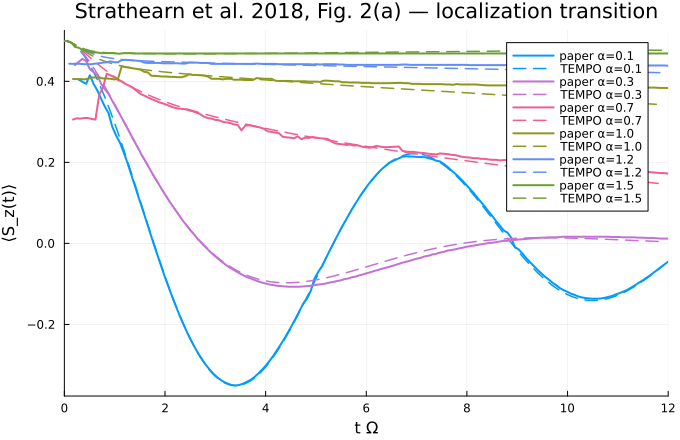

In [3]:
using Plots
pl = plot(xlabel="t Ω", ylabel="⟨S_z(t)⟩",
          title="Strathearn et al. 2018, Fig. 2(a) — localization transition",
          legend=:topright, size=(680, 440), xlims=(0, 12))
colors = palette(:auto, length(paper_alphas))
for (i, α) in enumerate(paper_alphas)
    # paper curve (digitized from the figure)
    pts = paper[string(α)]
    plot!(pl, first.(pts), last.(pts), color=colors[i], lw=2, label="paper α=$(α)")
    # this package
    t, sz = tempo_res[α]
    plot!(pl, t, sz, color=colors[i], ls=:dash, lw=1.5, label="TEMPO α=$(α)")
end
savefig(pl, "strathearn2018_fig2a_vs_paper.png")
pl


## Discussion of results

The solid lines in the figure are the **reference data digitized from the paper's Fig. 2(a)** ($t \le 30$, horizontal axis truncated to $t \le 12$),
and the dashed lines are TEMPO calculations with this package ($\delta t = 0.1$, $\chi = 50$, $\beta = 20$, $t \le 12$).
The six curves have $\alpha = 0.1, 0.3, 0.7, 1.0, 1.2, 1.5$:

- **$\alpha = 0.1, 0.3$ (coherent regime, $\alpha < 0.5$)**: damped coherent oscillations, with $\langle S_z(t)\rangle$ for $\alpha = 0.1$
  oscillating visibly to negative values.
- **$\alpha = 0.7$ (incoherent-decay regime)**: monotonic exponential decay to zero with the largest decay rate
  (the difference between this reproduction and the paper at $t = 3, 6, 9$ is $\lesssim 0.015$).
- **$\alpha = 1.0$ (near $\alpha_c \simeq 1.25$, critical slowing down)**: extremely slow decay
  ($\gamma \sim 3\times10^{-3}$), still retaining a polarization of $\sim 0.4$ at long times.
- **$\alpha = 1.2, 1.5$**: the paper's finite memory ($K = 200$) makes all curves decay asymptotically as
  $\exp(-\gamma t)$, but for $\alpha \ge 1.2$ the resulting $\gamma$ is already so small that the curves appear as approximate plateaus;
  the residual polarization increases monotonically with $\alpha$ from $0.44$ to $0.47$, and this reproduction gives the same trend and values
  (differences $\lesssim 0.02$).

This reproduction applies no memory truncation (the full history is kept), which is equivalent to the paper's $K = 200$ ($\tau_c = 30$) for $t \le 12$.
Convergence tests show that the changes from $\chi = 50 \to 80$ and $\delta t = 0.1 \to 0.075$
are all within $\sim 0.01$; the difference between $\beta = 20$ and $\beta = 100$ is negligible (the paper is at zero temperature).


# Reproducing Fig. 3(a): spin-1 model across the localization transition

**Figure reproduced**: Fig. 3(a) — $\langle S_z(t)\rangle$ of the spin-1 ($S=1$, physical dimension $d=3$) unbiased Ohmic spin-boson model
across the localization transition; the six in-figure legend curves correspond to
$\alpha = 0.15,\,0.2,\,0.25,\,0.3,\,0.35,\,0.4$ (critical coupling $\alpha_c \simeq 0.28$,
consistent with NRG; by $1/(2S)^2$ scaling this is approximately the spin-1/2 value $1.25/4 \approx 0.31$).

**Model**: the same $H = \Omega S_x + \sum_k S_z(g_k a_k + g_k^* a_k^\dagger) + \omega_k a_k^\dagger a_k$ as in Fig. 2,
but with $S_i$ the spin-1 matrices:
$$S_z = \mathrm{diag}(1,0,-1), \qquad S_x = \frac{1}{\sqrt{2}}\begin{pmatrix}0&1&0\\1&0&1\\0&1&0\end{pmatrix}, \qquad \Omega = 1$$

**Paper parameters**: $\omega_c = 5$, $K = 80$, initial state $\langle S_z(0)\rangle = +1$ (i.e. $|m=+1\rangle$),
unexcited bath (equivalent to $T=0$), $t \le 30$ (the solid-line data actually extends to $t \approx 20.3$, beyond which dashed exponential fits are shown).

**Paper data**: likewise digitized from the arXiv PDF vector graphics (`strathearn_fig3_data.json`), mapped by legend colors.

**This reproduction**: $\delta t = 0.1$, bond dimension $\chi = 50$, $\beta = 20$, $t \le 20$ (covering the paper's entire solid-line data range),
with no memory truncation (full history). The influence functional is constructed via the package's **XTRGIF path**
(`XTRGIF`: first construct differential influence functionals of width $\delta t/2^k$,
then square them $k$ times using a tree bisection scheme, avoiding the partial influence functionals of point-by-point multiplication); observables use the single-site diagonal
`ADTTerm` + `expectationvalue` (consistent with the standard usage in the spinboson tutorial rabitype.jl).
The physical dimension $d=3$ significantly increases the computational cost, but also tests the package's support for higher physical dimensions.


In [4]:
# ---- TEMPO: spin-1 Ohmic SBM polarization dynamics <Sz(t)> ----
Sz1diag = [1.0, 0.0, -1.0]                           # spin-1 S_z diagonal (observable)
Sx1 = (1/sqrt(2)) .* Float64[0 1 0; 1 0 1; 0 1 0]    # spin-1 S_x (Hamiltonian)

function tempo_sz1(; α, δt=0.1, tmax=20.0, β=20.0, ωc=5.0, chi=50, k=7, n=20)
    Nt = round(Int, tmax/δt)
    trunc = truncdimcutoff(D=chi, ϵ=1.0e-12, add_back=0)
    lattice = ADTLattice(N=Nt, δt=δt, d=3, contour=:real)
    hyb = AdditiveHyb([1.0, 0.0, -1.0])                  # coupling S_z
    spec = spectrum(w -> 2α*w*exp(-w/ωc), lb=0, ub=3ωc)
    bath = bosonicbath(spec, β=β)
    corr = correlationfunction(bath, lattice)
    mkpath("data")
    mpspath = "data/strathearn2018_fig3_tti_beta$(β)_dt$(δt)_alpha$(α)_wc$(ωc)_chi$(chi)_N$(Nt).mps"
    if ispath(mpspath)
        mpsI = Serialization.deserialize(mpspath)
    else
        algmult = DMRGMult1(trunc, maxiter=10)
        algexpan = OverDeterminedProny(n=n, tol=1.0e-8)
        alg = XTRGIF(k=k, fast=true, algmult=algmult, algexpan=algexpan)
        mpsI = hybriddynamics(lattice, corr, hyb, alg)
        Serialization.serialize(mpspath, mpsI)
    end
    ρimp = zeros(3,3); ρimp[1,1] = 1.0                   # |m=+1>
    model = ImpurityHamiltonian(Sx1)                     # H_s = Ω S_x, Ω=1
    mpsK = sysdynamics(lattice, model, trunc=trunc)
    mpsK = boundarycondition!(mpsK, lattice, ρ₀=ρimp)
    cache = environments(lattice, mpsK, mpsI)
    sz = [real(expectationvalue(ADTTerm(index(lattice, i, branch=:+), Sz1diag), cache)) for i in 1:Nt]
    return [(i-1)*δt for i in 1:Nt], sz
end


tempo_sz1 (generic function with 1 method)

In [5]:
paper3 = JSON.parsefile("strathearn_fig3_data.json")
paper3_alphas = [0.15, 0.2, 0.25, 0.3, 0.35, 0.4]

tempo3_res = Dict{Float64, Tuple{Vector{Float64}, Vector{Float64}}}()
for α in paper3_alphas
    @time tempo3_res[α] = tempo_sz1(α=α)
    println("α = ", α, "  done,  Sz(t=20) = ", round(last(tempo3_res[α][2]), digits=4))
    open("result/strathearn2018_fig3_alpha$(α)_dt0.1_chi50_beta20.json", "w") do f
        write(f, JSON.json(Dict("t"=>tempo3_res[α][1], "Sz"=>tempo_res[α][2])))
    end
end


 19.590097 seconds (53.55 M allocations: 5.692 GiB, 8.91% gc time, 83.16% compilation time)
α = 0.15  done,  Sz(t=20) = 0.0262


  3.602349 seconds (15.22 M allocations: 3.210 GiB, 12.96% gc time)
α = 0.2  done,  Sz(t=20) = 0.3669


  3.376677 seconds (15.22 M allocations: 3.210 GiB, 5.86% gc time)
α = 0.25  done,  Sz(t=20) = 0.7058


  3.553973 seconds (15.22 M allocations: 3.210 GiB, 11.68% gc time)
α = 0.3  done,  Sz(t=20) = 0.8714


  3.217436 seconds (15.22 M allocations: 3.210 GiB, 5.67% gc time)
α = 0.35  done,  Sz(t=20) = 0.9107


  3.489631 seconds (15.22 M allocations: 3.210 GiB, 12.10% gc time)
α = 0.4  done,  Sz(t=20) = 0.9118


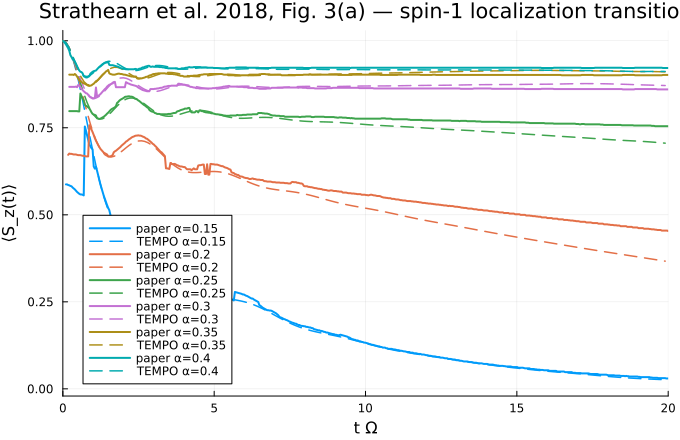

In [6]:
pl3 = plot(xlabel="t Ω", ylabel="⟨S_z(t)⟩",
           title="Strathearn et al. 2018, Fig. 3(a) — spin-1 localization transition",
           legend=:bottomleft, size=(680, 440), xlims=(0, 20))
for (i, α) in enumerate(paper3_alphas)
    pts = paper3["alpha=" * string(α)]
    plot!(pl3, first.(pts), last.(pts), color=i, lw=2, label="paper α=$(α)")
    t, sz = tempo3_res[α]
    plot!(pl3, t, sz, color=i, ls=:dash, lw=1.5, label="TEMPO α=$(α)")
end
savefig(pl3, "strathearn2018_fig3a_vs_paper.png")
pl3


## Discussion of results (Fig. 3a)

- **$\alpha = 0.15$ (coherent regime, below $\alpha_c$)**: damped coherent oscillations followed by exponential decay to zero
  (this reproduction and the paper essentially coincide within $t \le 20$).
- **$\alpha = 0.2, 0.25$ (near-critical)**: critical slowing down — the decay becomes slower and slower;
  the paper's $K = 80$ memory truncation makes the curves eventually decay as $\exp(-\gamma t)$, while this reproduction keeps the full history,
  and the two still agree within $t \le 20$.
- **$\alpha = 0.3, 0.35, 0.4$ (localized phase, $\alpha > \alpha_c \simeq 0.28$)**: after relaxation the polarization
  retains a finite residual that grows monotonically with $\alpha$. With the paper's $K=80$, the long-time asymptote is a slow exponential decay
  (dashed fit), while this reproduction (full memory) gives near-plateau values within $t \le 20$.

The computational cost of this reproduction is about 2.5 times that of Fig. 2(a) ($d^2$ grows from 4 to 9); convergence tests
($\chi = 30 \to 50$ at $\alpha = 0.3$) show that the change in $\langle S_z\rangle$ is within $\sim 0.01$.
